# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [93]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [94]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

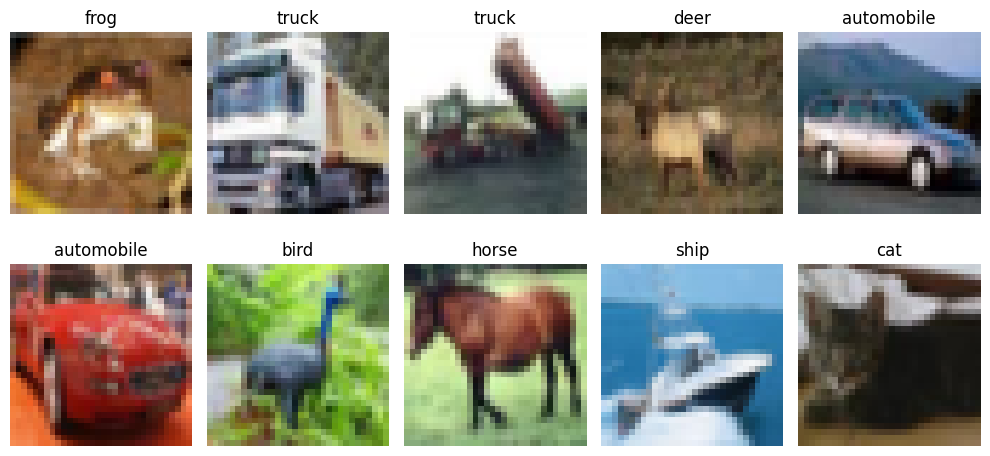

In [95]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [96]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [97]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2662 - loss: 2.0026 - val_accuracy: 0.3252 - val_loss: 1.8750
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3076 - loss: 1.8829 - val_accuracy: 0.3554 - val_loss: 1.8159
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3299 - loss: 1.8341 - val_accuracy: 0.3576 - val_loss: 1.7828
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3390 - loss: 1.8112 - val_accuracy: 0.3672 - val_loss: 1.7708
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3456 - loss: 1.7855 - val_accuracy: 0.3798 - val_loss: 1.7325
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3545 - loss: 1.7712 - val_accuracy: 0.3996 - val_loss: 1.7283
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3562 - loss: 1.7557 - val_accuracy: 0.4066 - val_loss: 1.7062
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3660 - loss: 1.7380 - val_accuracy: 0.

In [98]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4003 - loss: 1.6824
ANN Test Accuracy: 0.400299996137619


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [99]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4751 - loss: 1.4875 - val_accuracy: 0.5348 - val_loss: 1.2990
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6048 - loss: 1.1259 - val_accuracy: 0.5406 - val_loss: 1.3331
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6632 - loss: 0.9586 - val_accuracy: 0.6414 - val_loss: 1.0623
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7068 - loss: 0.8401 - val_accuracy: 0.6748 - val_loss: 0.9523
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7412 - loss: 0.7385 - val_accuracy: 0.6944 - val_loss: 0.9060
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7627 - loss: 0.6717 - val_accuracy: 0.6242 - val_loss: 1.1957
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7907 - loss: 0.5944 - val_accuracy: 0.6696 - val_loss: 1.0547
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8080 - loss: 0.5380 - val_accuracy: 

In [100]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7133 - loss: 0.9716
CNN Test Accuracy: 0.7132999897003174


## 📈 Compare Learning Curves

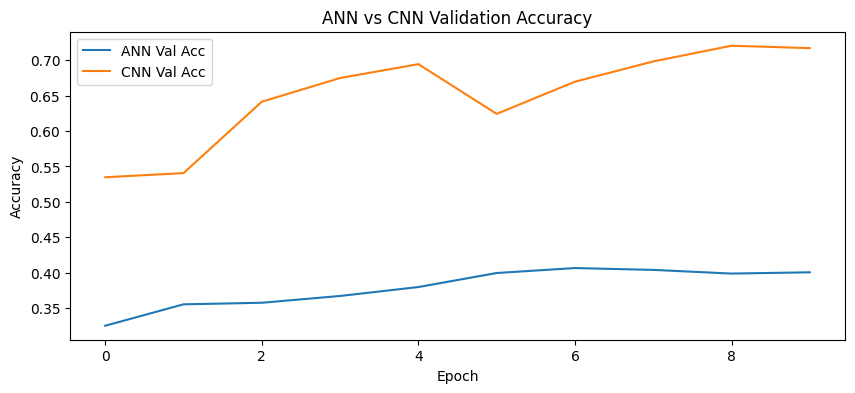

In [101]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [102]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3715 - loss: 1.7232 - val_accuracy: 0.4742 - val_loss: 1.4647
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4736 - loss: 1.4671 - val_accuracy: 0.5680 - val_loss: 1.1999
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5128 - loss: 1.3698 - val_accuracy: 0.5802 - val_loss: 1.1774
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5318 - loss: 1.3157 - val_accuracy: 0.6082 - val_loss: 1.0968
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5443 - loss: 1.2818 - val_accuracy: 0.6170 - val_loss: 1.0816
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5567 - loss: 1.2570 - val_accuracy: 0.6180 - val_loss: 1.0819
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5642 - loss: 1.2317 - val_accuracy: 0.6274 - val_loss: 1.0943
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.5735 - loss: 1.

# 📊 Final Comparison Table

In [103]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4003
1,CNN,0.7133


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

**1.Increasing the layers and epochs in ANN**

In [104]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_new = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2555 - loss: 2.0252 - val_accuracy: 0.3298 - val_loss: 1.8470
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3092 - loss: 1.8795 - val_accuracy: 0.3598 - val_loss: 1.7941
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3280 - loss: 1.8331 - val_accuracy: 0.3852 - val_loss: 1.7717
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3397 - loss: 1.8020 - val_accuracy: 0.3774 - val_loss: 1.7571
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3484 - loss: 1.7747 - val_accuracy: 0.3858 - val_loss: 1.7494
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3602 - loss: 1.7584 - val_accuracy: 0.3950 - val_loss: 1.6946
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3628 - loss: 1.7442 - val_accuracy: 0.4054 - val_loss: 1.6868
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3753 - loss: 1.7238 - val_accuracy: 0.

In [105]:
ann_test_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4370 - loss: 1.6186
ANN Test Accuracy: 0.43700000643730164


After adding an extra layer and increasing the epochs to 20 the accuracy_score has slightly increased  so we can say the performance is better.

**2.Adding 3 CNN Filters from 32->64->128 and increasing the epochs to 20 and adding EarlyStopping**

In [116]:
cnn_model = models.Sequential([layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
                               layers.MaxPooling2D(), layers.Conv2D(64, (3,3), activation='relu'),
                               layers.MaxPooling2D(), layers.Conv2D(128, (3,3), activation='relu'),
                               layers.MaxPooling2D(), layers.Flatten(), layers.Dense(128, activation='relu'), layers.Dense(10, activation='softmax')])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

cnn_history_new = cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4152 - loss: 1.5915 - val_accuracy: 0.5296 - val_loss: 1.2818
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5738 - loss: 1.1996 - val_accuracy: 0.5980 - val_loss: 1.1185
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6330 - loss: 1.0461 - val_accuracy: 0.6548 - val_loss: 0.9958
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6731 - loss: 0.9332 - val_accuracy: 0.6638 - val_loss: 0.9615
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7032 - loss: 0.8505 - val_accuracy: 0.7008 - val_loss: 0.8799
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7289 - loss: 0.7807 - val_accuracy: 0.7090 - val_loss: 0.8447
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7487 - loss: 0.7211 - val_accuracy: 0.7058 - val_loss: 0.8650
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7684 - loss: 0.6640 - val_accuracy: 0.

In [117]:
cnn_test_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7230 - loss: 0.8258
CNN Test Accuracy: 0.7229999899864197


Their is no much improvement in performance by increasing epochs extra epochs

**Training the Added Data Augmentation**

In [108]:
aug_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7718 - loss: 0.6483 - val_accuracy: 0.7139 - val_loss: 0.9286
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7745 - loss: 0.6393 - val_accuracy: 0.7090 - val_loss: 0.9666
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7760 - loss: 0.6323 - val_accuracy: 0.7052 - val_loss: 0.9722
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7787 - loss: 0.6278 - val_accuracy: 0.7032 - val_loss: 0.9577
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7752 - loss: 0.6360 - val_accuracy: 0.7050 - val_loss: 0.9653
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7747 - loss: 0.6328 - val_accuracy: 0.6964 - val_loss: 1.0202
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7783 - loss: 0.6296 - val_accuracy: 0.7080 - val_loss: 0.9535
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7778 - loss: 0.6305 - 

In [109]:
acc_score = aug_model.evaluate(x_test_norm, y_test)[1]
print("Accuracy Score:", acc_score)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7125 - loss: 0.9458
Accuracy Score: 0.7124999761581421


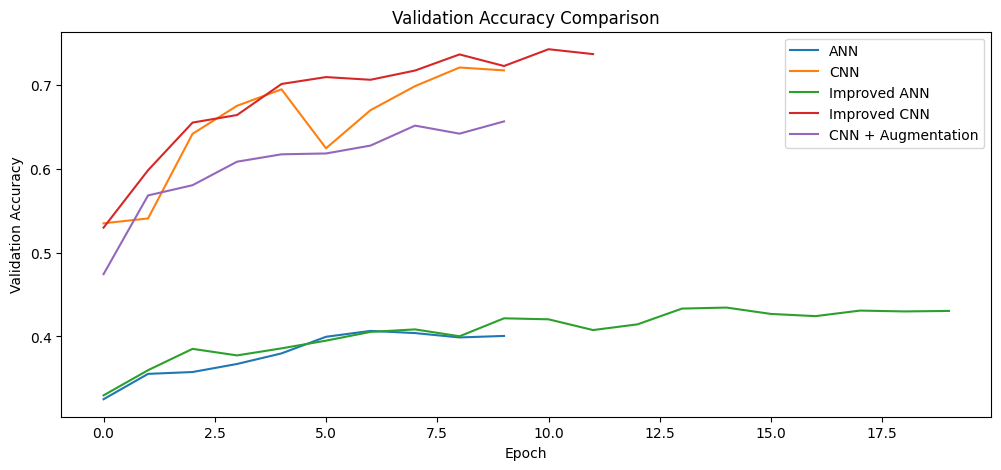

In [118]:
plt.figure(figsize=(12,5))

plt.plot(ann_history.history['val_accuracy'],label='ANN')

plt.plot(cnn_history.history['val_accuracy'],label='CNN')

plt.plot(ann_history_new.history['val_accuracy'],label='Improved ANN')

plt.plot(cnn_history_new.history['val_accuracy'],label='Improved CNN')

plt.plot(aug_history.history['val_accuracy'],label='CNN + Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

In [119]:
comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Improved ANN",
        "Improved CNN",
        "CNN + Augmentation"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        ann_acc,
        cnn_acc,
        acc_score
    ]
})

comparison["Test Accuracy"] = comparison["Test Accuracy"].round(4)

comparison

,Model,Test Accuracy
0,ANN,0.4003
1,CNN,0.7133
2,Improved ANN,0.4370
3,Improved CNN,0.7230
4,CNN + Augmentation,0.7125


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**